# Differential Expression: Unbiased

This notebook inspects full-gene pseudobulk differential expression results for broad Harmony classes and excitatory-focus subclasses. It can also regenerate the full DE result tables when needed.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sys.path.append(str(Path("../src").resolve()))
from c9_snrnaseq.io_utils import PROJECT_ROOT


In [2]:
RESULTS_DIR = PROJECT_ROOT / "results"
DE_BROAD_DIR = RESULTS_DIR / "de_pseudobulk_broad"
DE_EXC_DIR = RESULTS_DIR / "de_pseudobulk_exc_focus"
FIGURES_DIR = RESULTS_DIR / "figures"

for d in [RESULTS_DIR, DE_BROAD_DIR, DE_EXC_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

adata_merged_pb = sc.read_h5ad(PROJECT_ROOT / "data/processed/merged/adata_merged_pb_exc_focus.h5ad")

print(adata_merged_pb.shape)
print("Has counts:", "counts" in adata_merged_pb.layers)
print("Has cell_class_major_harmony:", "cell_class_major_harmony" in adata_merged_pb.obs.columns)
print("Has exc_subclass_focus:", "exc_subclass_focus" in adata_merged_pb.obs.columns)
print(adata_merged_pb.obs["exc_subclass_focus"].value_counts(dropna=False))


(89819, 61552)
Has counts: True
Has cell_class_major_harmony: True
Has exc_subclass_focus: True
exc_subclass_focus
NaN                      70013
Other_excitatory         15810
Projection_like_SCN4B     2198
Broad_IT_exc              1592
UMN_like_VAT1L             206
Name: count, dtype: int64


In [3]:
broad_main_classes = [
    "Microglia",
    "Excitatory_neurons",
    "Astrocytes",
    "Inhibitory_neurons",
    "OPCs",
]

exc_focus_de_classes = [
    "Projection_like_SCN4B",
    "Broad_IT_exc",
]

pairwise_tests = [
    ("Control", "sALS"),
    ("Control", "c9ALS"),
    ("sALS", "c9ALS"),
]


In [ ]:
def pseudobulk_by_sample(
    adata,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts",
):
    sub = adata[adata.obs[groupby_col] == group_value].copy()
    if sub.n_obs == 0:
        raise ValueError(f"No cells found for {groupby_col}={group_value!r}.")

    cell_counts = sub.obs["sample"].value_counts()
    keep_samples = cell_counts[cell_counts >= min_cells_per_sample].index.tolist()
    if not keep_samples:
        raise ValueError(
            f"No samples retained for {groupby_col}={group_value!r} "
            f"with min_cells_per_sample={min_cells_per_sample}."
        )

    sub = sub[sub.obs["sample"].isin(keep_samples)].copy()
    sample_order = sorted(sub.obs["sample"].unique())
    pb_counts = []
    pb_meta = []

    for samp in sample_order:
        ss = sub[sub.obs["sample"] == samp]
        x = ss.layers[layer]
        if hasattr(x, "toarray"):
            x = x.toarray()
        pb_counts.append(np.asarray(x.sum(axis=0)).ravel())
        pb_meta.append({
            "sample": samp,
            "condition": ss.obs["condition"].iloc[0],
            "group_value": group_value,
            "groupby_col": groupby_col,
            "n_cells": ss.n_obs,
        })

    counts_df = pd.DataFrame(pb_counts, index=sample_order, columns=sub.var_names)
    meta_df = pd.DataFrame(pb_meta).set_index("sample")
    return counts_df, meta_df


def run_pairwise_deseq(counts_df, meta_df, group_a, group_b):
    keep = meta_df["condition"].isin([group_a, group_b])
    counts_use = counts_df.loc[keep].copy()
    meta_use = meta_df.loc[keep].copy()

    counts_use = counts_use.round().astype(int)

    dds = DeseqDataSet(
        counts=counts_use,
        metadata=meta_use,
        design_factors="condition",
        refit_cooks=True
    )
    dds.deseq2()

    stats = DeseqStats(dds, contrast=["condition", group_b, group_a])
    stats.summary()

    res = stats.results_df.copy()
    res["gene"] = res.index
    return res


In [5]:
# Optional regeneration step: rerun to refresh full-gene DE tables.
regenerate_full_de = False

if regenerate_full_de:
    broad_de_results = {}
    exc_focus_de_results = {}
    skipped_groups = []

    for ct in broad_main_classes:
        counts_df, meta_df = pseudobulk_by_sample(
            adata_merged_pb,
            group_value=ct,
            groupby_col="cell_class_major_harmony",
            min_cells_per_sample=20,
            layer="counts",
        )
        for g1, g2 in pairwise_tests:
            res = run_pairwise_deseq(counts_df, meta_df, g1, g2)
            res.to_csv(DE_BROAD_DIR / f"{ct}_{g1}_vs_{g2}.csv", index=False)
            broad_de_results[(ct, g1, g2)] = res

    for ct in exc_focus_de_classes:
        try:
            counts_df, meta_df = pseudobulk_by_sample(
                adata_merged_pb,
                group_value=ct,
                groupby_col="exc_subclass_focus",
                min_cells_per_sample=20,
                layer="counts",
            )
        except ValueError as e:
            skipped_groups.append((ct, str(e)))
            print(f"Skipping {ct}: {e}")
            continue

        for g1, g2 in pairwise_tests:
            res = run_pairwise_deseq(counts_df, meta_df, g1, g2)
            res.to_csv(DE_EXC_DIR / f"{ct}_{g1}_vs_{g2}.csv", index=False)
            exc_focus_de_results[(ct, g1, g2)] = res

    print("Skipped groups:", skipped_groups)
else:
    print("Using previously saved full-gene DE result tables.")


Using previously saved full-gene DE result tables.


In [20]:
RESULT_DIRS = {
    "broad": DE_BROAD_DIR,
    "exc_focus": DE_EXC_DIR,
}

def format_comparison_for_display(comparison):
    g1, g2 = comparison.split("_vs_")
    return f"{g2} vs {g1}"


def load_de_result(analysis_level, group_name, comparison, suffix=".csv"):
    fn = RESULT_DIRS[analysis_level] / f"{group_name}_{comparison}{suffix}"
    if not fn.exists():
        raise FileNotFoundError(f"Result file not found: {fn}")
    df = pd.read_csv(fn)
    df["analysis_level"] = analysis_level
    df["group_name"] = group_name
    df["comparison"] = comparison
    return df


def plot_volcano(analysis_level, group_name, comparison, genes_to_label=None, padj_cutoff=0.1, lfc_cutoff=0.5, suffix=".csv"):
    df = load_de_result(analysis_level, group_name, comparison, suffix=suffix).dropna(subset=["padj", "log2FoldChange"]).copy()
    df["neglog10_padj"] = -np.log10(df["padj"].clip(lower=1e-300))
    df["sig"] = "NS"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] > lfc_cutoff), "sig"] = "Up"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] < -lfc_cutoff), "sig"] = "Down"

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {"NS": "lightgray", "Up": "firebrick", "Down": "steelblue"}
    for label in ["NS", "Up", "Down"]:
        sub = df[df["sig"] == label]
        ax.scatter(sub["log2FoldChange"], sub["neglog10_padj"], s=28, alpha=0.8, color=colors[label], label=label)

    if genes_to_label:
        label_df = df[df["gene"].isin(genes_to_label)].copy()
        for _, row in label_df.iterrows():
            ax.text(row["log2FoldChange"], row["neglog10_padj"], row["gene"], fontsize=8)

    ax.axvline(lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axvline(-lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axhline(-np.log10(padj_cutoff), linestyle="--", color="black", linewidth=1)
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(f"{group_name} | {format_comparison_for_display(comparison)}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return df


def plot_log2fc_heatmap(analysis_level, group_names, comparisons, genes=None, top_n_per_result=20, padj_cutoff=0.1, suffix=".csv", ytick_fontsize=8):
    long_dfs = []
    selected_genes = set(genes or [])

    for group_name in group_names:
        for comparison in comparisons:
            df = load_de_result(analysis_level, group_name, comparison, suffix=suffix).dropna(subset=["padj", "log2FoldChange"]).copy()
            df["row"] = f"{group_name} | {format_comparison_for_display(comparison)}"
            long_dfs.append(df[["gene", "row", "log2FoldChange", "padj"]])
            if top_n_per_result is not None:
                top = df[df["padj"] < padj_cutoff].sort_values("padj").head(top_n_per_result)
                selected_genes.update(top["gene"].tolist())

    long_df = pd.concat(long_dfs, ignore_index=True)
    if selected_genes:
        long_df = long_df[long_df["gene"].isin(selected_genes)].copy()
    mat = long_df.pivot_table(index="gene", columns="row", values="log2FoldChange", fill_value=0)
    if mat.empty:
        raise ValueError("No genes available for the requested selection.")
    mat = mat.loc[mat.abs().max(axis=1).sort_values(ascending=False).index]

    vmax = np.nanmax(np.abs(mat.values)) if mat.size else 1
    fig_h = max(8, 0.28 * max(len(mat.index), 1))
    fig, ax = plt.subplots(figsize=(14, fig_h))
    im = ax.imshow(mat.values, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=ytick_fontsize)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_title(f"log2FC heatmap | {analysis_level}")
    plt.colorbar(im, ax=ax, label="log2 fold change")
    plt.tight_layout()
    plt.show()
    return mat


def summarize_gene(gene, analysis_level, group_names, comparisons, suffix=".csv"):
    rows = []
    for group_name in group_names:
        for comparison in comparisons:
            df = load_de_result(analysis_level, group_name, comparison, suffix=suffix)
            df["comparison"] = format_comparison_for_display(comparison)
            hit = df[df["gene"] == gene].copy()
            if not hit.empty:
                rows.append(hit)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    keep_cols = [c for c in ["analysis_level", "group_name", "comparison", "gene", "log2FoldChange", "padj", "pvalue", "baseMean"] if c in out.columns]
    return out[keep_cols].sort_values(["group_name", "comparison"]).reset_index(drop=True)


def summarize_top_hits_all_genes(analysis_level, group_name, comparison, padj_cutoff=0.1, lfc_cutoff=0.0, top_n=30, sort_by="padj", suffix=".csv"):
    df = load_de_result(analysis_level, group_name, comparison, suffix=suffix).dropna(subset=["padj", "log2FoldChange"]).copy()
    df = df[(df["padj"] < padj_cutoff) & (df["log2FoldChange"].abs() > lfc_cutoff)]
    if sort_by == "padj":
        df = df.sort_values(["padj", "baseMean"], ascending=[True, False])
    elif sort_by == "abs_lfc":
        df = df.assign(abs_lfc=df["log2FoldChange"].abs()).sort_values(["abs_lfc", "padj"], ascending=[False, True])
    return df.head(top_n)[["gene", "log2FoldChange", "padj", "baseMean"]]


def plot_gene_by_condition(
    adata,
    gene,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts",
    normalisation="CPM",
    figsize=(6, 5),
):
    counts_df, meta_df = pseudobulk_by_sample(
        adata,
        group_value=group_value,
        groupby_col=groupby_col,
        min_cells_per_sample=min_cells_per_sample,
        layer=layer,
    )

    if gene not in counts_df.columns:
        raise ValueError(f"{gene} not found in pseudobulk counts.")

    plot_df = meta_df.copy()

    if normalisation.upper() == "CPM":
        libsize = counts_df.sum(axis=1)
        expr = np.log1p(counts_df.div(libsize, axis=0) * 1e6)
        ylab = f"log1p(CPM) of {gene}"
    else:
        expr = np.log1p(counts_df[gene])
        ylab = f"log1p(raw pseudobulk count) of {gene}"

    plot_df["expr"] = expr[gene] if normalisation.upper() == "CPM" else expr

    cond_order = ["Control", "sALS", "c9ALS"]
    x_pos = {cond: i for i, cond in enumerate(cond_order)}

    fig, ax = plt.subplots(figsize=figsize)

    for cond in cond_order:
        sub = plot_df[plot_df["condition"] == cond].copy()
        if sub.empty:
            continue

        jitter = np.linspace(-0.08, 0.08, len(sub)) if len(sub) > 1 else np.array([0.0])
        xs = np.full(len(sub), x_pos[cond]) + jitter

        ax.scatter(xs, sub["expr"], s=50, alpha=0.9, label=cond)

        for x, (_, row) in zip(xs, sub.iterrows()):
            ax.text(x, row["expr"], row.name, fontsize=7, alpha=0.8)

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels(cond_order)
    ax.set_ylabel(ylab)
    ax.set_title(f"{gene} in {group_value}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return plot_df


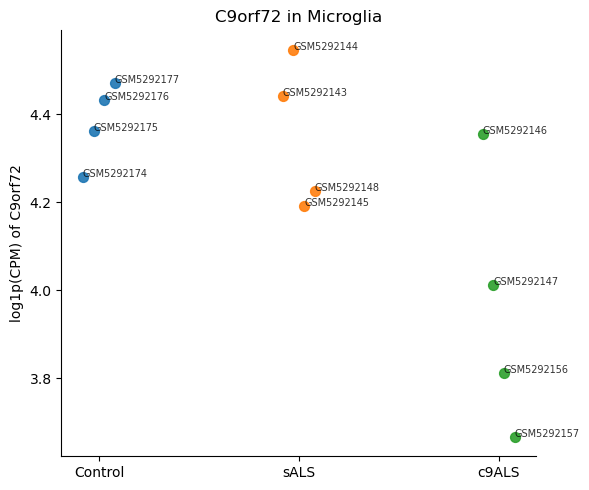

,condition,group_value,groupby_col,n_cells,expr
sample,,,,,
GSM5292143,sALS,Microglia,cell_class_major_harmony,1426,4.442467
GSM5292144,sALS,Microglia,cell_class_major_harmony,2669,4.547430
GSM5292145,sALS,Microglia,cell_class_major_harmony,1448,4.191293
GSM5292146,c9ALS,Microglia,cell_class_major_harmony,1502,4.355311
GSM5292147,c9ALS,Microglia,cell_class_major_harmony,1638,4.012283
GSM5292148,sALS,Microglia,cell_class_major_harmony,2169,4.226084
GSM5292156,c9ALS,Microglia,cell_class_major_harmony,1353,3.812415
GSM5292157,c9ALS,Microglia,cell_class_major_harmony,1279,3.666062
GSM5292174,Control,Microglia,cell_class_major_harmony,1191,4.258758


In [16]:
plot_gene_by_condition(
    adata_merged_pb,
    gene="C9orf72",
    group_value="Microglia",
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
)


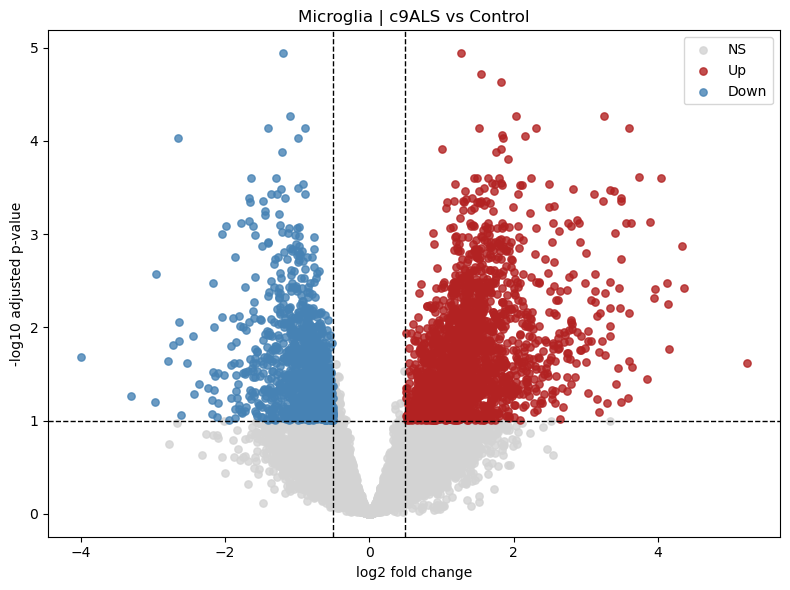

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,analysis_level,group_name,comparison,neglog10_padj,sig
2,82.259864,-0.407956,0.239942,-1.700227,0.089088,0.277939,ATAD3B,broad,Microglia,Control_vs_c9ALS,0.556050,NS
10,15.193121,-0.317845,0.438160,-0.725410,0.468201,0.702373,PRDM16,broad,Microglia,Control_vs_c9ALS,0.153432,NS
11,6.327143,-0.131702,0.685640,-0.192086,0.847675,0.933668,MTND2P28,broad,Microglia,Control_vs_c9ALS,0.029808,NS
12,264.838320,-0.486727,0.184083,-2.644058,0.008192,0.064628,ACAP3,broad,Microglia,Control_vs_c9ALS,1.189580,NS
16,13.906283,0.577577,0.462275,1.249422,0.211511,0.461460,PUSL1,broad,Microglia,Control_vs_c9ALS,0.335866,NS
...,...,...,...,...,...,...,...,...,...,...,...,...
61519,30.801363,1.305936,0.414794,3.148399,0.001642,0.023516,ENSG00000276256,broad,Microglia,Control_vs_c9ALS,1.628634,Up
61524,519.544988,-0.226833,0.463715,-0.489165,0.624725,0.807093,ENSG00000273748,broad,Microglia,Control_vs_c9ALS,0.093076,NS
61529,13.470326,-0.450856,0.606757,-0.743058,0.457447,0.695316,ENSG00000278817,broad,Microglia,Control_vs_c9ALS,0.157818,NS
61537,18.191618,-1.030700,0.597424,-1.725239,0.084484,0.270128,ENSG00000278384,broad,Microglia,Control_vs_c9ALS,0.568431,NS


In [21]:
plot_volcano(
    # analysis_level can be "broad" or "exc_focus".
    analysis_level="broad",
    # group_name can be 
        # broad: "Excitatory_neurons", "Inhibitory_neurons", "Astrocytes", "Microglia", "OPCs".
        # exc_focus: "Projection_like_SCN4B", "Broad_IT_exc".
    group_name="Microglia",
    # comparison can be "Control_vs_sALS", "Control_vs_c9ALS", "sALS_vs_c9ALS".
    comparison="Control_vs_c9ALS"
)

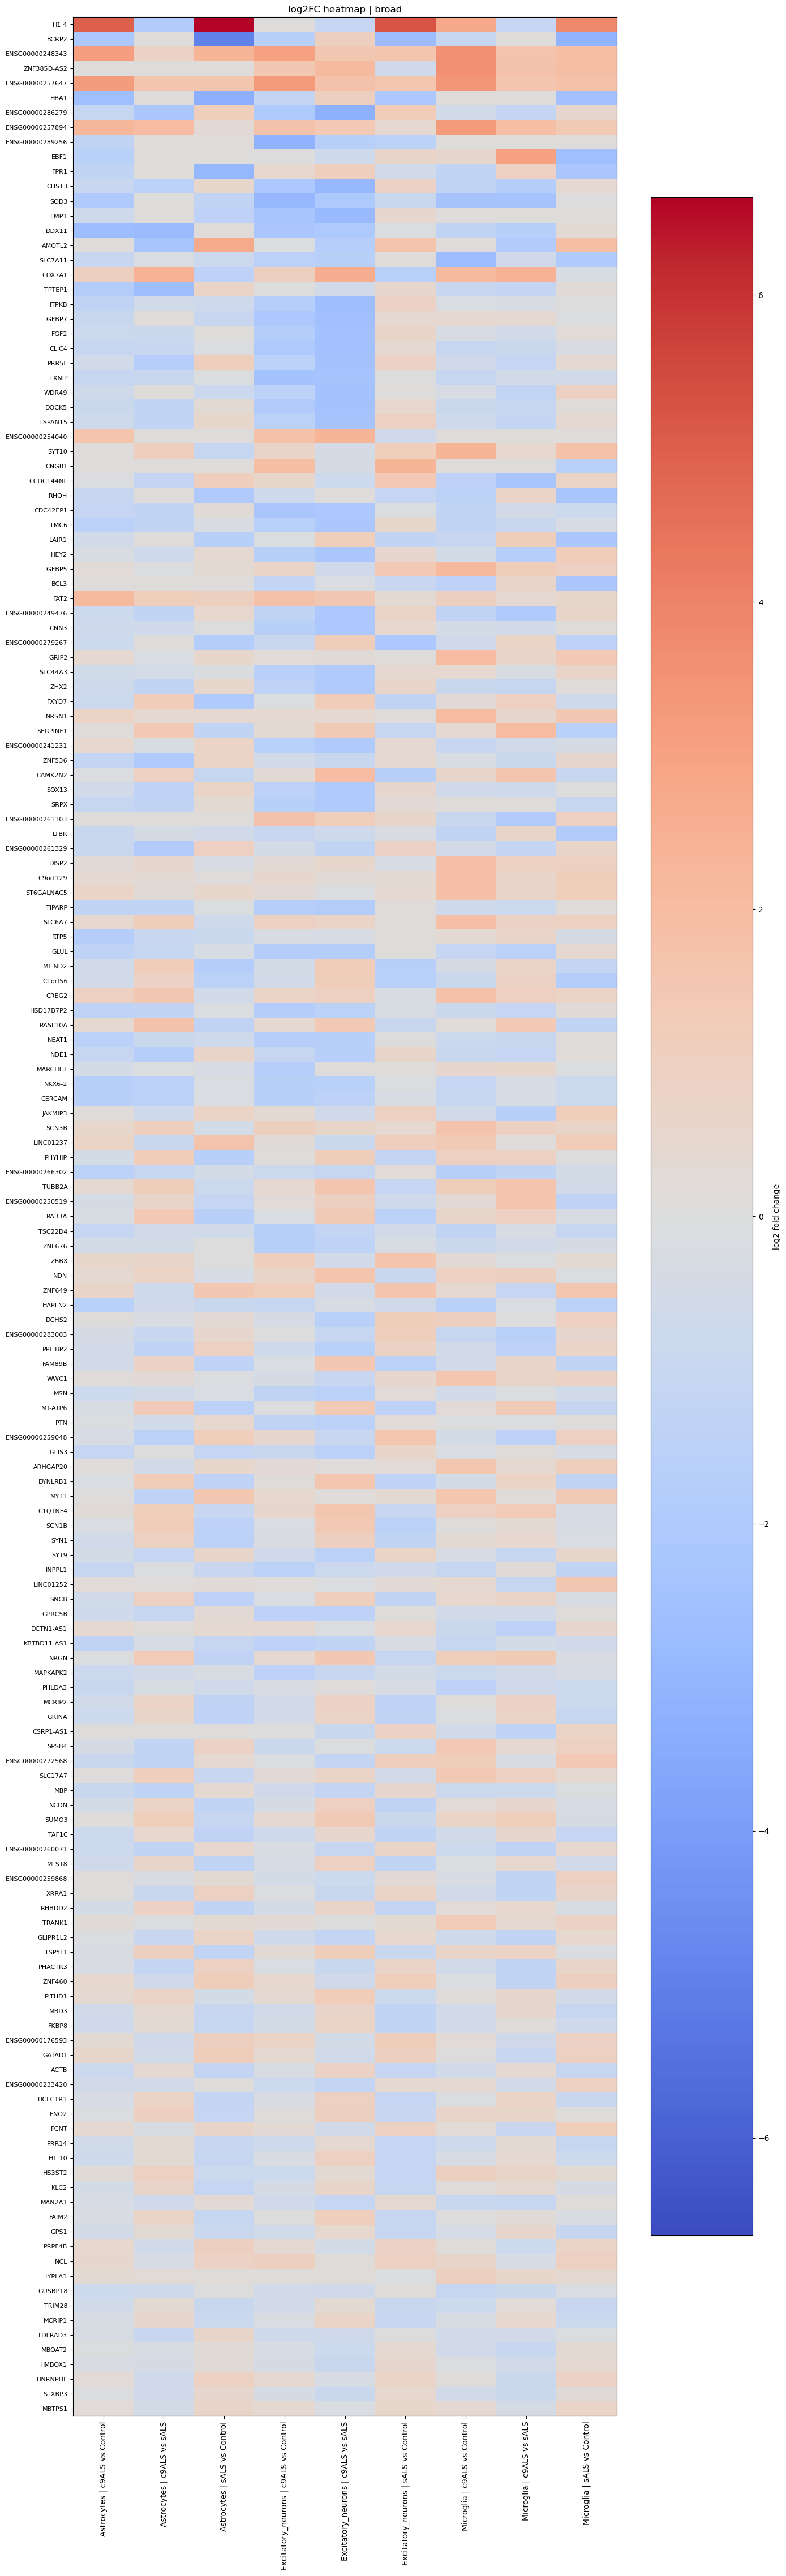

row,Astrocytes | c9ALS vs Control,Astrocytes | c9ALS vs sALS,Astrocytes | sALS vs Control,Excitatory_neurons | c9ALS vs Control,Excitatory_neurons | c9ALS vs sALS,Excitatory_neurons | sALS vs Control,Microglia | c9ALS vs Control,Microglia | c9ALS vs sALS,Microglia | sALS vs Control
gene,,,,,,,,,
H1-4,4.947944,-1.870103,6.633522,0.000000,-1.100796,5.243120,2.746787,-1.093326,3.788492
BCRP2,-2.108725,0.000000,-4.961569,-1.683141,1.018998,-2.709684,-0.997304,0.000000,-3.107937
ENSG00000248343,3.151001,0.845201,2.300525,3.029588,1.470025,1.570031,3.602803,1.678024,1.916550
ZNF385D-AS2,0.000000,0.000000,0.000000,1.425669,2.096342,-0.631380,3.600069,1.719751,1.901252
ENSG00000257647,3.170575,1.588763,1.585666,3.245877,1.715175,1.548221,3.386549,1.554812,1.792808
...,...,...,...,...,...,...,...,...,...
MBOAT2,-0.068442,-0.274117,0.205302,-0.356961,-0.741729,0.393659,-0.557707,-0.944793,0.347644
HMBOX1,-0.230307,-0.391437,0.160375,-0.404875,-0.913791,0.519102,-0.109037,-0.561834,0.416209
HNRNPDL,0.256318,-0.639575,0.892665,0.426173,-0.311126,0.745027,0.037902,-0.866413,0.863105


In [22]:
plot_log2fc_heatmap(
    analysis_level="broad",
    group_names=["Microglia", "Excitatory_neurons", "Astrocytes"],
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
    genes=None,
    top_n_per_result=20,
)


In [23]:
summarize_top_hits_all_genes(
    analysis_level="broad",
    group_name="Microglia",
    comparison="Control_vs_c9ALS",
    top_n=30,
)

,gene,log2FoldChange,padj,baseMean
59336,CDC42EP1,-1.195678,0.000011,228.259716
11788,TRANK1,1.267964,0.000011,199.169134
17929,WWC1,1.550680,0.000019,89.013105
593,ST6GALNAC5,1.829924,0.000023,164.869367
36597,NKX6-2,-1.093510,0.000053,1008.801496
38889,ENSG00000257894,3.247660,0.000053,116.546265
9958,GRIP2,2.036713,0.000053,87.488352
28712,ZHX2,-0.890176,0.000073,893.221047
4786,PHLDA3,-1.402838,0.000073,223.437059
35139,ARHGAP20,1.526310,0.000073,179.887975
